# Playa Quinta — Nearshore Wave Climate Analysis

Analysis of the reconstructed offshore-to-nearshore-to-breaking wave record (RBF reconstruction from 150 SWAN cases, shoaled/refracted to breaking). Covers time series comparison, directional/energy analysis, storm analysis, and offshore-nearshore transformation statistics.

Storm analysis follows Splinter, Turner, Reinhardt & Ruessink (2017, *Earth Surface Processes and Landforms*) — storms are identified from the breaking wave height using a duration threshold rather than a peaks-over-threshold/GPD extreme value fit, and characterized by cumulative **storm hours** rather than individual peak magnitudes.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import xarray as xr

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RHO = 1025      # seawater density [kg/m3]
G = 9.81        # gravity [m/s2]

In [2]:
data = os.path.join('..', 'data', 'waves', 'quinta_wave_transformation_timeseries.csv')

df = pd.read_csv(data, parse_dates=['time'], index_col='time')
df['Hs_ratio'] = df['Hs_10m'] / df['Hs_offshore']
df.head()

,Hs_offshore,Tp_offshore,Dir,Hs_10m,Hs_10m_std,Dir_10m,Hb,Hb_std,hb,hb_std,phib,phib_std,cb,cb_std,Hs_ratio
time,,,,,,,,,,,,,,,
2000-01-01 00:00:00,2.125000,13.736183,204.36855,1.687403,1.002307,190.717504,2.220622,1.119768,2.783604,1.410192,5.904933,6.181520,5.177656,1.425809,0.794072
2000-01-01 01:00:00,2.112061,13.679054,204.62627,1.677353,0.929764,190.829706,2.209150,1.038614,2.769316,1.308109,5.949600,5.761522,5.164446,1.322442,0.794179
2000-01-01 02:00:00,2.098877,13.629250,204.81350,1.666923,0.868702,190.909781,2.197385,0.970322,2.754567,1.222183,5.976717,5.403099,5.150764,1.235465,0.794198
2000-01-01 03:00:00,2.084229,13.586281,205.05855,1.656234,0.796389,191.014746,2.185364,0.889471,2.739342,1.120431,6.014528,4.973327,5.136681,1.132498,0.794651
2000-01-01 04:00:00,2.070068,13.549171,205.26685,1.645906,0.731768,191.103784,2.173802,0.817238,2.724608,1.029506,6.043902,4.584792,5.123003,1.040512,0.795098


## 1. Time series — offshore vs. nearshore

One arbitrary month, shown as two stacked panels so both series stay readable at their own scale. Change `month` to inspect a different period.

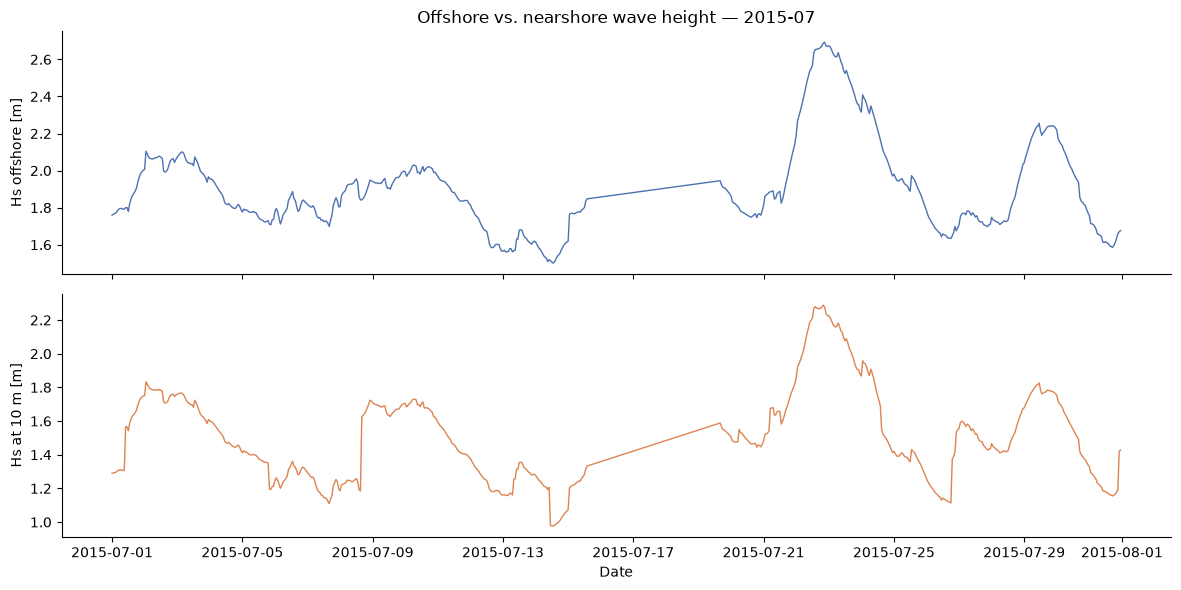

In [3]:
month = "2015-07"
window = df.loc[month]

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axs[0].plot(window.index, window['Hs_offshore'], color='#4C72B0', linewidth=1)
axs[0].set_ylabel('Hs offshore [m]')
axs[0].set_title(f'Offshore vs. nearshore wave height — {month}')

axs[1].plot(window.index, window['Hs_10m'], color='#DD8452', linewidth=1)
axs[1].set_ylabel('Hs at 10 m [m]')
axs[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

## 2. Directional energy analysis

Offshore wave power flux (deep-water approximation, $P = \frac{\rho g^2}{64\pi} H_s^2 T_p$), binned by 10° direction sectors, to identify which approach direction carries the most energy.

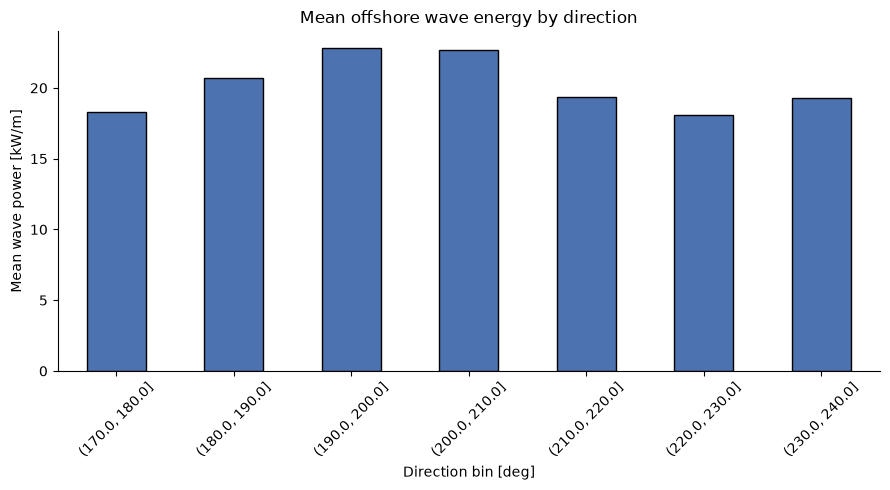

most energetic direction bin: (190.0, 200.0]  (22.9 kW/m)


In [4]:
df['P_offshore'] = (RHO * G**2 / (64 * np.pi)) * df['Hs_offshore']**2 * df['Tp_offshore'] / 1000  # kW/m

dmin = np.floor(df['Dir'].min() / 10) * 10
dmax = np.ceil(df['Dir'].max() / 10) * 10
dir_bins = np.arange(dmin, dmax + 10, 10)
df['Dir_bin'] = pd.cut(df['Dir'], bins=dir_bins)

energy_by_dir = df.groupby('Dir_bin', observed=True)['P_offshore'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
energy_by_dir.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='black')
ax.set_ylabel('Mean wave power [kW/m]')
ax.set_xlabel('Direction bin [deg]')
ax.set_title('Mean offshore wave energy by direction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

most_energetic = energy_by_dir.idxmax()
print(f"most energetic direction bin: {most_energetic}  ({energy_by_dir.max():.1f} kW/m)")

## 3. Monthly energy analysis

Same wave power metric, broken down by calendar month, and by month **and** direction together to see seasonal shifts in which direction dominates.

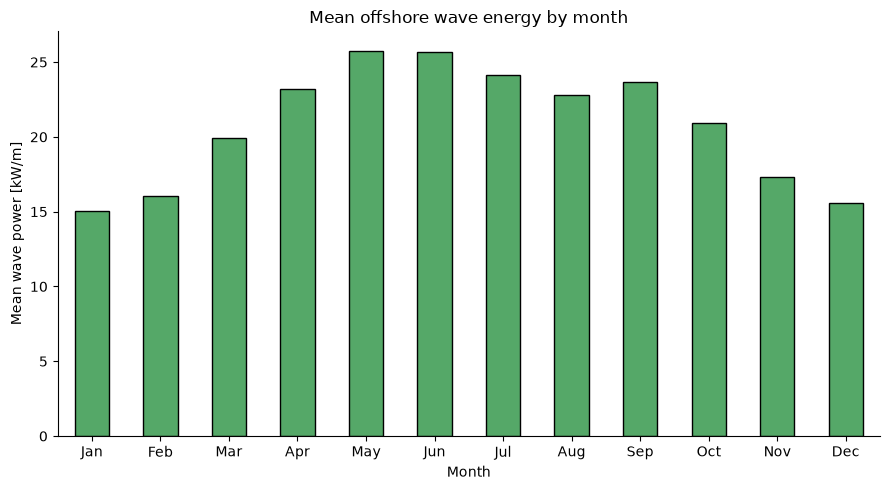

In [5]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_energy = df.groupby(df.index.month)['P_offshore'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
monthly_energy.plot(kind='bar', ax=ax, color='#55A868', edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Mean wave power [kW/m]')
ax.set_title('Mean offshore wave energy by month')
ax.set_xticklabels(month_labels, rotation=0)
plt.tight_layout()
plt.show()

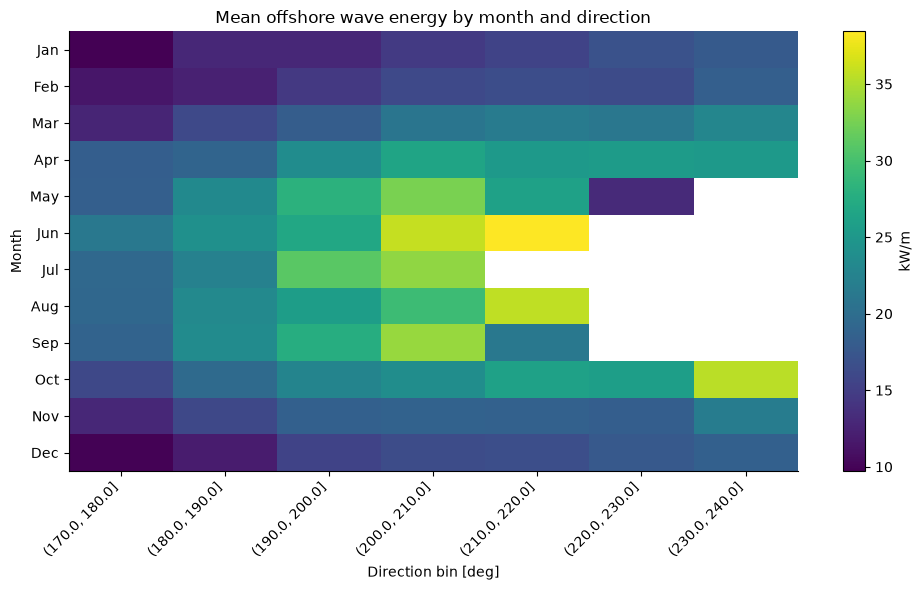

In [6]:
pivot = df.pivot_table(values='P_offshore', index=df.index.month, columns='Dir_bin', aggfunc='mean', observed=True)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([month_labels[m - 1] for m in pivot.index])
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], rotation=45, ha='right')
ax.set_xlabel('Direction bin [deg]')
ax.set_ylabel('Month')
ax.set_title('Mean offshore wave energy by month and direction')
plt.colorbar(im, ax=ax, label='kW/m')
plt.tight_layout()
plt.show()

## 4. Storm identification — storm hours (Masselink et al., 2014 / Splinter et al., 2017)

Storms are identified directly from the **breaking** wave height (`Hb` — already shoaled/refracted to the depth-limited breakpoint in the earlier transformation pipeline, same quantity Splinter et al. use `Hsb` for). A storm is defined as a period where `Hb` exceeds the 75th-percentile threshold (`H75`) for at least 24 continuous hours, **and** reaches the 95th-percentile threshold (`H95`) at some point during that period. The storm starts when `Hb` first crosses `H75` and ends when it drops back below `H75` — so the storm's duration captures the whole event, not just an instantaneous peak. This is deliberately different from a peaks-over-threshold/declustering approach: the quantity of interest here is cumulative **storm hours**, not a single peak magnitude per event.

In [7]:
hb_series = df['Hb'].dropna()

H95 = hb_series.quantile(0.95)
H75 = hb_series.quantile(0.75)
print(f"H75 (storm threshold):             {H75:.2f} m")
print(f"H95 (storm confirmation threshold): {H95:.2f} m")

above = hb_series > H75
group_id = (above != above.shift()).cumsum()

storm_rows = []
for gid, seg in hb_series[above].groupby(group_id[above]):
    if len(seg) < 24:            # minimum 24 continuous hours above H75
        continue
    if seg.max() < H95:          # must reach H95 at some point
        continue
    start, end = seg.index[0], seg.index[-1]
    peak_time = seg.idxmax()
    storm_rows.append({
        'start': start, 'end': end,
        'storm_hours': len(seg),
        'Hb_peak': seg.max(), 'Hb_mean': seg.mean(),
        'peak_time': peak_time,
        'direction': df.loc[peak_time, 'Dir'],
    })

storm_cols = ['start', 'end', 'storm_hours', 'Hb_peak', 'Hb_mean', 'peak_time', 'direction']
storms = pd.DataFrame(storm_rows, columns=storm_cols).sort_values('start').reset_index(drop=True)
if len(storms) > 0:
    storms['year'] = storms['start'].dt.year
    storms['month'] = storms['start'].dt.month
    storms['recovery_days'] = (storms['start'] - storms['end'].shift()).dt.total_seconds() / 86400
else:
    storms['year'] = storms['month'] = storms['recovery_days'] = pd.Series(dtype=float)
    print("no storms met the H75/24h/H95 criteria -- check H75/H95 look reasonable above, "
          "and that Hb has realistic multi-day persistence (not just hourly noise)")

print(f"storms identified: {len(storms)}")
print(f"mean storm duration: {storms['storm_hours'].mean():.1f} h")
print(f"mean inter-storm recovery time: {storms['recovery_days'].mean():.1f} days")
storms.head()

H75 (storm threshold):             2.05 m
H95 (storm confirmation threshold): 2.45 m
storms identified: 291
mean storm duration: 94.2 h
mean inter-storm recovery time: 29.1 days


,start,end,storm_hours,Hb_peak,Hb_mean,peak_time,direction,year,month,recovery_days
0,2000-04-01 15:00:00,2000-04-03 23:00:00,57,2.489733,2.323340,2000-04-02 05:00:00,208.31150,2000,4,NaN
1,2000-05-11 04:00:00,2000-05-17 05:00:00,146,2.493201,2.295232,2000-05-12 22:00:00,203.59450,2000,5,37.208333
2,2000-05-17 14:00:00,2000-05-23 04:00:00,135,2.779927,2.543039,2000-05-21 02:00:00,192.26233,2000,5,0.375000
3,2000-05-31 21:00:00,2000-06-03 16:00:00,68,2.512067,2.336515,2000-06-02 01:00:00,204.14456,2000,5,8.708333
4,2000-06-06 20:00:00,2000-06-09 13:00:00,66,2.665939,2.435396,2000-06-07 22:00:00,187.79181,2000,6,3.166667


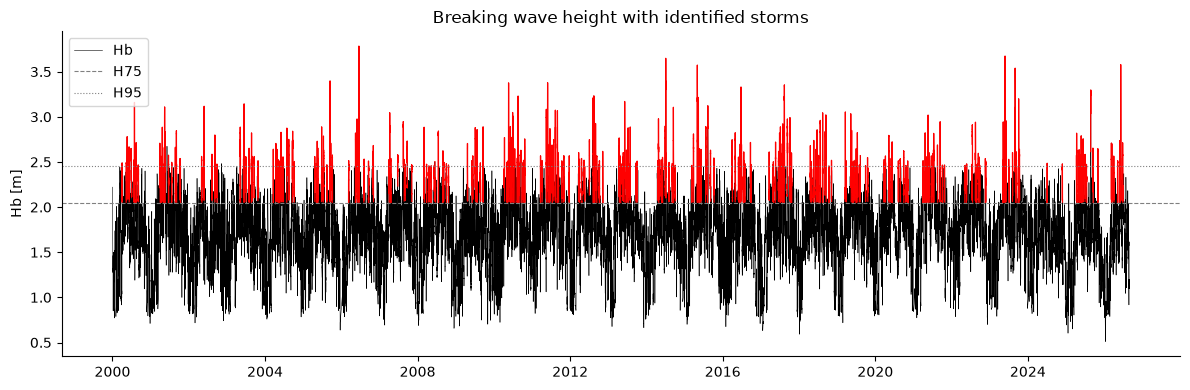

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hb_series.index, hb_series.values, color='black', linewidth=0.4, label='Hb')
for _, s in storms.iterrows():
    seg = hb_series.loc[s['start']:s['end']]
    ax.plot(seg.index, seg.values, color='red', linewidth=0.9)
ax.axhline(H75, color='gray', linestyle='--', linewidth=0.8, label='H75')
ax.axhline(H95, color='gray', linestyle=':', linewidth=0.8, label='H95')
ax.set_ylabel('Hb [m]')
ax.set_title('Breaking wave height with identified storms')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Storm hours — annual and seasonal distribution

Reproduces the core figures from Splinter et al. (2017): cumulative storm hours per year (stacked by month, with a linear trend), and the average monthly distribution of storm hours — plus a check of whether the first-half-of-year (JJ) vs second-half-of-year (JD) storm hours differ significantly, as they did at the Gold Coast pre-2005.

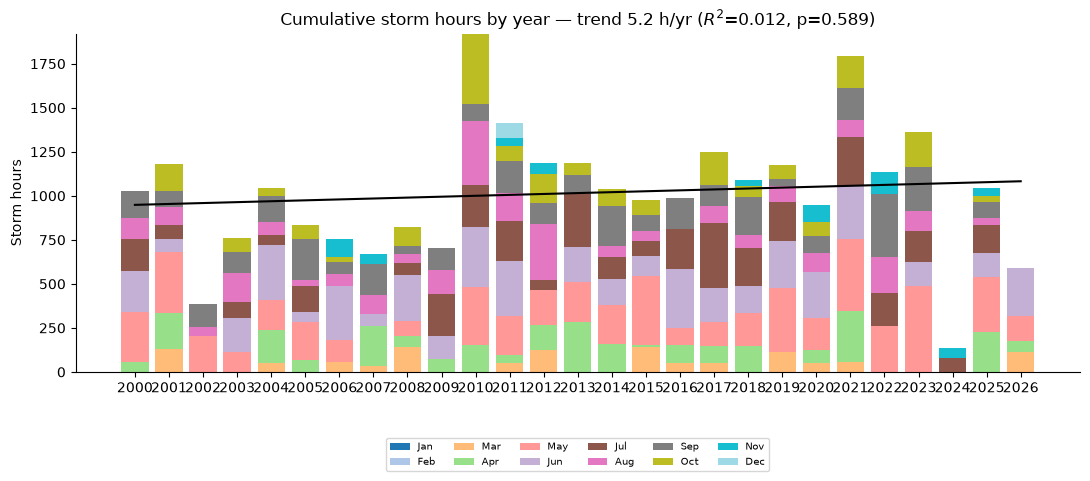

In [9]:
# expand each storm into its individual hourly Hb records, tagged by year/month --
# this attributes storm hours correctly even when a storm spans a month or year boundary
storm_hours_rows = []
for _, s in storms.iterrows():
    seg = hb_series.loc[s['start']:s['end']]
    for t in seg.index:
        storm_hours_rows.append({'time': t, 'year': t.year, 'month': t.month})
storm_hours_df = pd.DataFrame(storm_hours_rows)

pivot_year_month = storm_hours_df.pivot_table(
    index='year', columns='month', values='time', aggfunc='count', fill_value=0
)
for m in range(1, 13):
    if m not in pivot_year_month.columns:
        pivot_year_month[m] = 0
pivot_year_month = pivot_year_month[sorted(pivot_year_month.columns)]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(pivot_year_month))
colors = plt.cm.tab20(np.linspace(0, 1, 12))
for m in range(1, 13):
    vals = pivot_year_month[m].values
    ax.bar(pivot_year_month.index.astype(str), vals, bottom=bottom, color=colors[m - 1], label=month_labels[m - 1])
    bottom += vals

yearly_total = pivot_year_month.sum(axis=1)
years_numeric = pivot_year_month.index.values.astype(float)
slope, intercept, r, p_val, se = stats.linregress(years_numeric, yearly_total.values)
trend = slope * years_numeric + intercept
ax.plot(pivot_year_month.index.astype(str), trend, color='black', linewidth=1.5)

ax.set_ylabel('Storm hours')
ax.set_title(f'Cumulative storm hours by year — trend {slope:.1f} h/yr ($R^2$={r**2:.3f}, p={p_val:.3f})')
ax.legend(ncol=6, fontsize=7, bbox_to_anchor=(0.5, -0.18), loc='upper center')
plt.tight_layout()
plt.show()

In [15]:
coverage = df.groupby(df.index.year).size()
print(coverage)
print(f"\nrecord spans: {df.index.min()} to {df.index.max()}")
print(f"2024 hours present: {coverage.get(2024, 0)}  (full year = 8760/8784)")

if 2024 in df.index.year.unique():
    n = len(df.loc['2024'])
    nan_hb = df.loc['2024', 'Hb'].isna().sum()
    print(f"2024: {nan_hb}/{n} hours have NaN Hb ({100*nan_hb/n:.1f}%)")

time
2000    7416
2001    7603
2002    7693
2003    7934
2004    7780
2005    7918
2006    8013
2007    7629
2008    7962
2009    8227
2010    7906
2011    8170
2012    7753
2013    8034
2014    7827
2015    7781
2016    7374
2017    7615
2018    8045
2019    8022
2020    8208
2021    7925
2022    8466
2023    7972
2024    7745
2025    8126
2026    5144
dtype: int64

record spans: 2000-01-01 00:00:00 to 2026-08-27 21:00:00
2024 hours present: 7745  (full year = 8760/8784)
2024: 0/7745 hours have NaN Hb (0.0%)


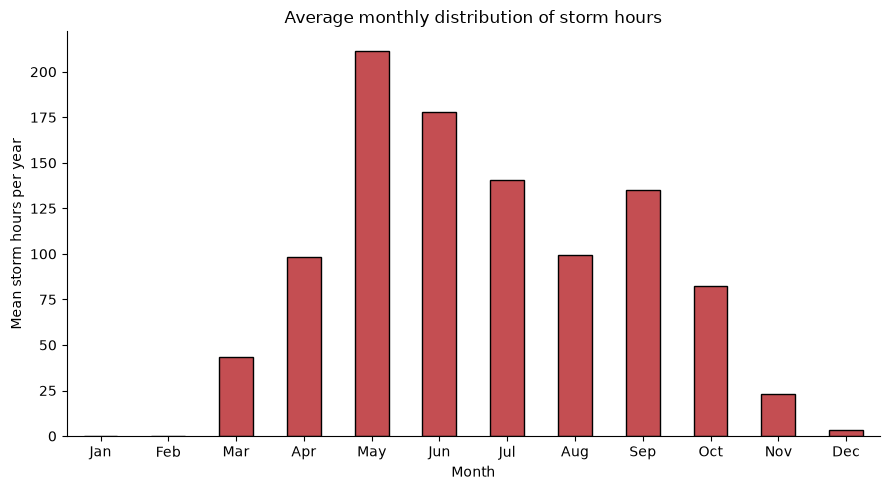

In [10]:
monthly_storm_hours = storm_hours_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
monthly_storm_hours = monthly_storm_hours / storm_hours_df['year'].nunique()   # average per year on record

fig, ax = plt.subplots(figsize=(9, 5))
monthly_storm_hours.plot(kind='bar', ax=ax, color='#C44E52', edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Mean storm hours per year')
ax.set_title('Average monthly distribution of storm hours')
ax.set_xticklabels(month_labels, rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# JJ (Jan-Jun) vs JD (Jul-Dec) storm hours per year -- same seasonality check as the paper
storm_hours_df['half'] = np.where(storm_hours_df['month'] <= 6, 'JJ (Jan-Jun)', 'JD (Jul-Dec)')
seasonal_hours = storm_hours_df.groupby(['year', 'half']).size().unstack(fill_value=0)

print(seasonal_hours.mean().rename('mean storm hours/year'))

t_stat, p_val = stats.ttest_ind(seasonal_hours['JJ (Jan-Jun)'], seasonal_hours['JD (Jul-Dec)'])
print(f"\nJJ vs JD storm hours per year: t = {t_stat:.2f}, p = {p_val:.3f}"
      f"  ({'significant' if p_val < 0.05 else 'not significant'} at 95%)")

half
JD (Jul-Dec)    483.814815
JJ (Jan-Jun)    531.777778
Name: mean storm hours/year, dtype: float64

JJ vs JD storm hours per year: t = 0.75, p = 0.455  (not significant at 95%)


In [19]:
# Hardcoded ENSO classification (ONI-based), restricted to events overlapping the wave record.
# Each "YYYY-YY+1" ENSO year is taken as 1 Jul YYYY - 30 Jun YYYY+1 (centers the window on the
# DJF peak) -- exact onset/offset shifts by a couple months event to event, close enough for
# shading a yearly bar chart.
ENSO_EVENTS = [
    (2000, 'nina', 'weak'),
    (2002, 'nino', 'moderate'),
    (2004, 'nino', 'weak'),
    (2005, 'nina', 'weak'),
    (2006, 'nino', 'weak'),
    (2007, 'nina', 'strong'),
    (2008, 'nina', 'weak'),
    (2009, 'nino', 'moderate'),
    (2010, 'nina', 'strong'),
    (2011, 'nina', 'moderate'),
    (2014, 'nino', 'weak'),
    (2015, 'nino', 'very strong'),
    (2016, 'nina', 'weak'),
    (2017, 'nina', 'weak'),
    (2018, 'nino', 'weak'),
    (2019, 'nino', 'weak'),
    (2020, 'nina', 'moderate'),
    (2021, 'nina', 'moderate'),
    (2022, 'nina', 'weak'),
    (2023, 'nino', 'strong'),
]

enso_df = pd.DataFrame([
    {'start': pd.Timestamp(f"{y}-07-01"), 'end': pd.Timestamp(f"{y+1}-06-30"), 'phase': p, 'intensity': i}
    for y, p, i in ENSO_EVENTS
])

PHASE_COLOR = {'nino': 'orange', 'nina': 'steelblue'}
INTENSITY_ALPHA = {'weak': 0.10, 'moderate': 0.22, 'strong': 0.35, 'very strong': 0.5}

In [20]:
## Storm intensity — cumulative dissipated wave energy, not just duration
#
# Breaking wave power per unit crest length: P_b = (1/16) rho g Hb^2 cb  [W/m]
# (same energy-density form as P_offshore earlier, but using the shallow-water group velocity
# at breaking, cb, instead of deep-water Cg). Summing P_b over each storm's hourly record gives
# a cumulative storm energy [kWh/m] that distinguishes "many hours of middling surf" from
# "a genuinely energetic event" -- storm_hours alone can't tell those apart.

df['P_break'] = (RHO * G * df['Hb']**2 * df['cb']) / 16 / 1000   # kW/m

storms['storm_energy_kWhm'] = [
    df.loc[s['start']:s['end'], 'P_break'].sum() for _, s in storms.iterrows()
]

storms[['start', 'end', 'storm_hours', 'Hb_peak', 'storm_energy_kWhm']] \
    .sort_values('storm_energy_kWhm', ascending=False).head(10)

,start,end,storm_hours,Hb_peak,storm_energy_kWhm
237,2021-05-10 04:00:00,2021-05-25 10:00:00,367,3.019313,7530.606274
173,2016-06-20 11:00:00,2016-07-02 13:00:00,291,3.330396,6883.526446
13,2001-05-08 05:00:00,2001-05-20 01:00:00,285,3.109415,6590.303759
240,2021-07-05 18:00:00,2021-07-17 06:00:00,277,2.816545,6010.469038
266,2023-08-29 00:00:00,2023-09-07 10:00:00,227,3.538850,5757.606858
98,2010-06-27 11:00:00,2010-07-08 11:00:00,222,3.047980,5098.978028
53,2005-09-12 04:00:00,2005-09-23 10:00:00,229,3.397469,5084.551443
117,2011-08-30 06:00:00,2011-09-07 06:00:00,193,3.067353,4485.923424
93,2010-05-19 09:00:00,2010-05-26 16:00:00,176,3.375812,4235.272514
289,2026-06-02 21:00:00,2026-06-10 00:00:00,172,3.578215,4208.505635


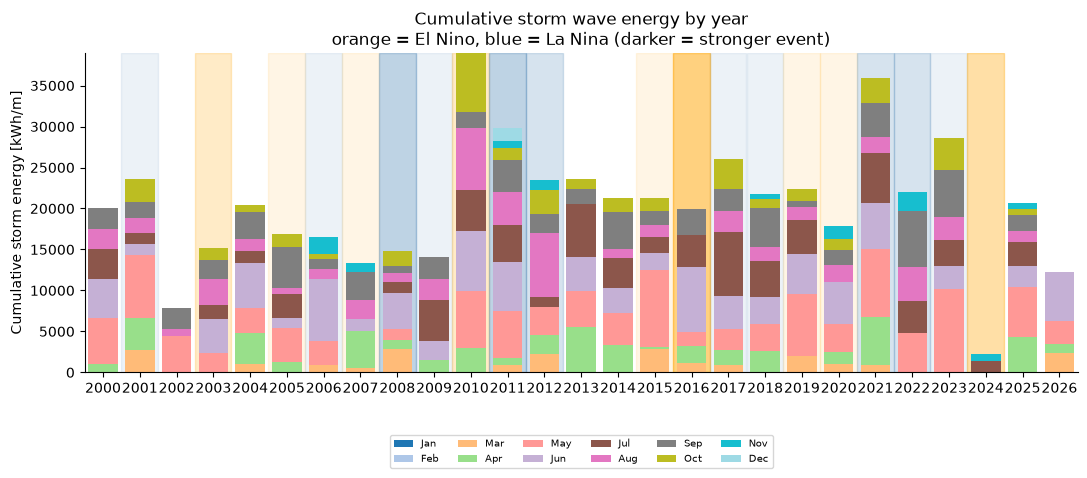

In [21]:
# expand to hourly records again, this time carrying P_break so it can be summed per year/month
storm_hours_df['P_break'] = df.loc[storm_hours_df['time'], 'P_break'].values

pivot_energy = storm_hours_df.pivot_table(index='year', columns='month', values='P_break', aggfunc='sum', fill_value=0)
for m in range(1, 13):
    if m not in pivot_energy.columns:
        pivot_energy[m] = 0
pivot_energy = pivot_energy[sorted(pivot_energy.columns)]
years_e = pivot_energy.index.values.astype(float)

fig, ax = plt.subplots(figsize=(11, 5))

for _, ev in enso_df.iterrows():
    ax.axvspan(ev['start'].year + (ev['start'].dayofyear - 1) / 365.25,
               ev['end'].year + (ev['end'].dayofyear - 1) / 365.25,
               color=PHASE_COLOR[ev['phase']], alpha=INTENSITY_ALPHA[ev['intensity']], zorder=0)

bottom = np.zeros(len(pivot_energy))
colors = plt.cm.tab20(np.linspace(0, 1, 12))
for m in range(1, 13):
    vals = pivot_energy[m].values
    ax.bar(years_e, vals, bottom=bottom, width=0.8, color=colors[m - 1], label=month_labels[m - 1], zorder=2)
    bottom += vals

ax.set_xticks(years_e)
ax.set_xticklabels(pivot_energy.index.astype(str), rotation=0)
ax.set_xlim(years_e.min() - 0.5, years_e.max() + 0.5)
ax.set_ylabel('Cumulative storm energy [kWh/m]')
ax.set_title('Cumulative storm wave energy by year\norange = El Nino, blue = La Nina (darker = stronger event)')
ax.legend(ncol=6, fontsize=7, bbox_to_anchor=(0.5, -0.18), loc='upper center')
plt.tight_layout()
plt.show()

In [22]:
## Strongest individual storms — ranked by mean intensity, not cumulative energy or duration
#
# storm_energy_kWhm / storm_hours gives the storm's AVERAGE power while active [kW/m] --
# this strips duration out entirely, so a short-but-intense storm and a long-but-mild one are
# now properly distinguishable (cumulative energy still rewards duration; storm_hours ignores
# intensity altogether).

storms['P_break_mean_kWm'] = storms['storm_energy_kWhm'] / storms['storm_hours']
storms['year_frac'] = storms['start'].dt.year + (storms['start'].dt.dayofyear - 1) / 365.25

def classify_phase(date):
    for _, ev in enso_df.iterrows():
        if ev['start'] <= date <= ev['end']:
            return ev['phase'], ev['intensity']
    return 'neutral', None

storms[['phase', 'enso_intensity']] = storms['start'].apply(lambda d: pd.Series(classify_phase(d)))

top_storms = storms.sort_values('P_break_mean_kWm', ascending=False).reset_index(drop=True)
top_storms[['start', 'end', 'storm_hours', 'Hb_peak', 'P_break_mean_kWm', 'phase', 'enso_intensity']].head(15)

,start,end,storm_hours,Hb_peak,P_break_mean_kWm,phase,enso_intensity
0,2025-08-24 08:00:00,2025-08-25 21:00:00,38,3.297377,37.037356,neutral,NaN
1,2006-06-17 04:00:00,2006-06-21 07:00:00,100,3.783342,33.967809,nina,weak
2,2015-04-30 15:00:00,2015-05-05 19:00:00,125,3.572895,31.020104,nino,weak
3,2017-08-12 02:00:00,2017-08-15 05:00:00,76,3.353802,28.857169,nina,weak
4,2007-08-16 11:00:00,2007-08-18 12:00:00,50,2.947661,28.620824,nina,strong
5,2014-07-01 13:00:00,2014-07-06 19:00:00,127,3.648276,28.540402,nino,weak
6,2012-08-02 22:00:00,2012-08-06 16:00:00,91,3.207748,28.064044,neutral,NaN
7,2023-05-24 12:00:00,2023-05-29 06:00:00,115,3.673113,27.069443,nina,weak
8,2015-08-09 16:00:00,2015-08-11 19:00:00,52,3.122524,26.864550,nino,very strong
9,2013-06-04 21:00:00,2013-06-08 08:00:00,84,3.170044,26.254991,neutral,NaN


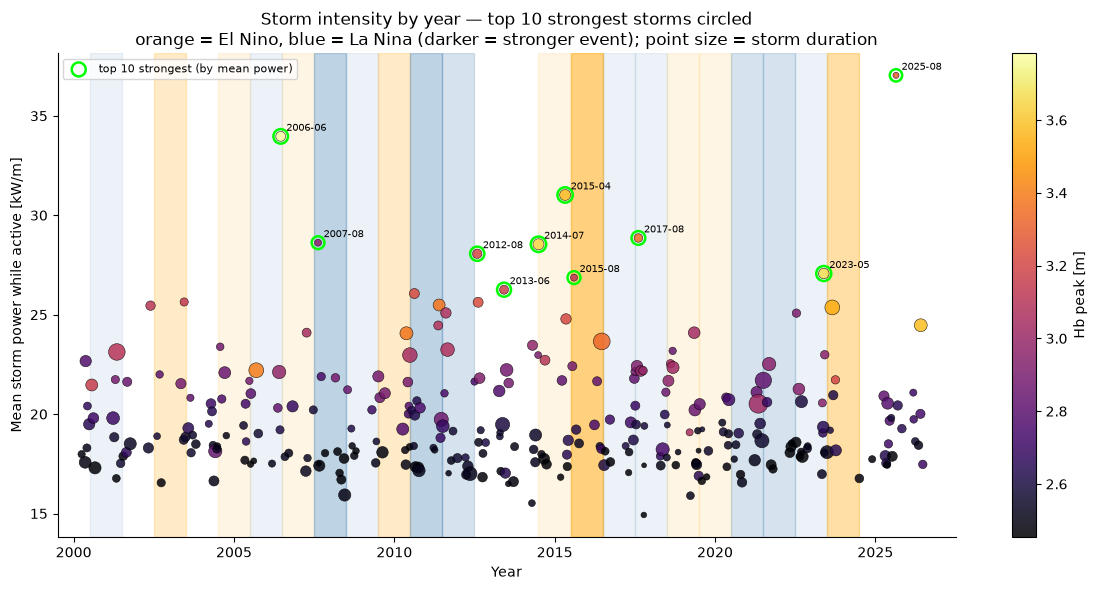

In [23]:
N_TOP = 10
top_n = top_storms.head(N_TOP)

fig, ax = plt.subplots(figsize=(12, 6))

for _, ev in enso_df.iterrows():
    ax.axvspan(ev['start'].year + (ev['start'].dayofyear - 1) / 365.25,
               ev['end'].year + (ev['end'].dayofyear - 1) / 365.25,
               color=PHASE_COLOR[ev['phase']], alpha=INTENSITY_ALPHA[ev['intensity']], zorder=0)

sc = ax.scatter(storms['year_frac'], storms['P_break_mean_kWm'],
                 s=storms['storm_hours'] / 2, c=storms['Hb_peak'], cmap='inferno',
                 edgecolor='black', linewidth=0.4, alpha=0.85, zorder=2)

ax.scatter(top_n['year_frac'], top_n['P_break_mean_kWm'],
           s=top_n['storm_hours'] / 2 + 60, facecolors='none', edgecolors='lime', linewidth=1.8, zorder=3,
           label=f'top {N_TOP} strongest (by mean power)')
for _, s in top_n.iterrows():
    ax.annotate(s['start'].strftime('%Y-%m'), (s['year_frac'], s['P_break_mean_kWm']),
                textcoords='offset points', xytext=(4, 4), fontsize=7)

plt.colorbar(sc, ax=ax, label='Hb peak [m]')
years_all = storms['year_frac']
ax.set_xlim(np.floor(years_all.min()) - 0.5, np.ceil(years_all.max()) + 0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Mean storm power while active [kW/m]')
ax.set_title(f'Storm intensity by year — top {N_TOP} strongest storms circled\n'
             'orange = El Nino, blue = La Nina (darker = stronger event); point size = storm duration')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
## Largest individual storms — ranked by cumulative energy (duration x intensity combined)
#
# This is the complement to the mean-power view above: storm_energy_kWhm rewards both a storm
# being intense AND lasting a long time, so it answers "which events actually delivered the
# most total wave energy to the coast" rather than "which were the most intense while active".

top_storms_cumulative = storms.sort_values('storm_energy_kWhm', ascending=False).reset_index(drop=True)
top_storms_cumulative[['start', 'end', 'storm_hours', 'Hb_peak', 'storm_energy_kWhm', 'phase', 'enso_intensity']].head(15)

,start,end,storm_hours,Hb_peak,storm_energy_kWhm,phase,enso_intensity
0,2021-05-10 04:00:00,2021-05-25 10:00:00,367,3.019313,7530.606274,nina,moderate
1,2016-06-20 11:00:00,2016-07-02 13:00:00,291,3.330396,6883.526446,nino,very strong
2,2001-05-08 05:00:00,2001-05-20 01:00:00,285,3.109415,6590.303759,nina,weak
3,2021-07-05 18:00:00,2021-07-17 06:00:00,277,2.816545,6010.469038,nina,moderate
4,2023-08-29 00:00:00,2023-09-07 10:00:00,227,3.538850,5757.606858,nino,strong
5,2010-06-27 11:00:00,2010-07-08 11:00:00,222,3.047980,5098.978028,nino,moderate
6,2005-09-12 04:00:00,2005-09-23 10:00:00,229,3.397469,5084.551443,nina,weak
7,2011-08-30 06:00:00,2011-09-07 06:00:00,193,3.067353,4485.923424,nina,moderate
8,2010-05-19 09:00:00,2010-05-26 16:00:00,176,3.375812,4235.272514,nino,moderate
9,2026-06-02 21:00:00,2026-06-10 00:00:00,172,3.578215,4208.505635,neutral,NaN


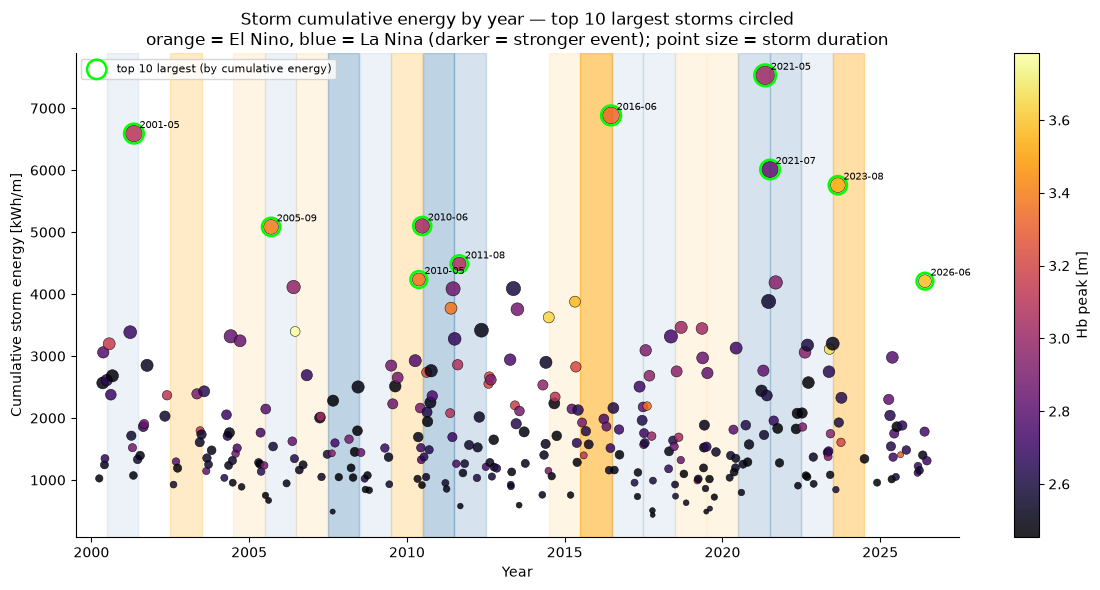

In [26]:
N_TOP = 10
top_n_cum = top_storms_cumulative.head(N_TOP)

fig, ax = plt.subplots(figsize=(12, 6))

for _, ev in enso_df.iterrows():
    ax.axvspan(ev['start'].year + (ev['start'].dayofyear - 1) / 365.25,
               ev['end'].year + (ev['end'].dayofyear - 1) / 365.25,
               color=PHASE_COLOR[ev['phase']], alpha=INTENSITY_ALPHA[ev['intensity']], zorder=0)

sc = ax.scatter(storms['year_frac'], storms['storm_energy_kWhm'],
                 s=storms['storm_hours'] / 2, c=storms['Hb_peak'], cmap='inferno',
                 edgecolor='black', linewidth=0.4, alpha=0.85, zorder=2)

ax.scatter(top_n_cum['year_frac'], top_n_cum['storm_energy_kWhm'],
           s=top_n_cum['storm_hours'] / 2 + 60, facecolors='none', edgecolors='lime', linewidth=1.8, zorder=3,
           label=f'top {N_TOP} largest (by cumulative energy)')
for _, s in top_n_cum.iterrows():
    ax.annotate(s['start'].strftime('%Y-%m'), (s['year_frac'], s['storm_energy_kWhm']),
                textcoords='offset points', xytext=(4, 4), fontsize=7)

plt.colorbar(sc, ax=ax, label='Hb peak [m]')
years_all = storms['year_frac']
ax.set_xlim(np.floor(years_all.min()) - 0.5, np.ceil(years_all.max()) + 0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative storm energy [kWh/m]')
ax.set_title(f'Storm cumulative energy by year — top {N_TOP} largest storms circled\n'
             'orange = El Nino, blue = La Nina (darker = stronger event); point size = storm duration')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [27]:
from scipy import stats

## 1. Categorical: storm intensity across ENSO phases
groups = {phase: storms.loc[storms['phase'] == phase, 'P_break_mean_kWm'].dropna()
          for phase in ['nino', 'nina', 'neutral']}
for phase, g in groups.items():
    print(f"{phase}: n={len(g)}, mean={g.mean():.1f} kW/m, median={g.median():.1f} kW/m")

h_stat, p_kw = stats.kruskal(*groups.values())
print(f"\nKruskal-Wallis across all three phases: H={h_stat:.2f}, p={p_kw:.3f}")

u_stat, p_mw = stats.mannwhitneyu(groups['nino'], groups['nina'], alternative='two-sided')
n1, n2 = len(groups['nino']), len(groups['nina'])
r_rb = 1 - (2 * u_stat) / (n1 * n2)   # rank-biserial effect size
print(f"Mann-Whitney U, El Nino vs La Nina only: U={u_stat:.1f}, p={p_mw:.3f}, effect size r={r_rb:.3f}")

nino: n=91, mean=20.1 kW/m, median=19.2 kW/m
nina: n=125, mean=19.6 kW/m, median=18.7 kW/m
neutral: n=75, mean=19.7 kW/m, median=18.6 kW/m

Kruskal-Wallis across all three phases: H=3.22, p=0.200
Mann-Whitney U, El Nino vs La Nina only: U=6466.0, p=0.086, effect size r=-0.137


In [28]:
## 2. Continuous: correlate storm intensity directly against the ONI value at storm time,
##    rather than a coarse 3-bucket phase label -- more statistical power, no arbitrary binning
oni_series = oni.set_index('date')['ANOM'].sort_index()
storms['ONI_at_storm'] = storms['start'].apply(
    lambda t: oni_series.reindex(oni_series.index.union([t])).interpolate().loc[t]
)

for col, label in [('P_break_mean_kWm', 'mean storm power'),
                    ('storm_energy_kWhm', 'cumulative storm energy'),
                    ('Hb_peak', 'peak Hb')]:
    r_s, p_s = stats.spearmanr(storms['ONI_at_storm'], storms[col])
    print(f"Spearman, ONI vs {label}: rho={r_s:.3f}, p={p_s:.3f}")

Spearman, ONI vs mean storm power: rho=0.104, p=0.076
Spearman, ONI vs cumulative storm energy: rho=-0.015, p=0.802
Spearman, ONI vs peak Hb: rho=0.168, p=0.004


In [29]:
## 3. Storm frequency by phase (count per year, not just intensity)
storm_counts = storms.groupby(storms['start'].dt.year)['start'].count().rename('n_storms')
year_phase = {yr: classify_phase(pd.Timestamp(f"{yr}-07-01"))[0] for yr in storm_counts.index}
storm_counts = pd.DataFrame(storm_counts).assign(phase=[year_phase[y] for y in storm_counts.index])

print(storm_counts.groupby('phase')['n_storms'].agg(['mean', 'median', 'count']))
h2, p2 = stats.kruskal(*[storm_counts.loc[storm_counts['phase'] == p, 'n_storms'] for p in ['nino', 'nina', 'neutral']])
print(f"\nKruskal-Wallis, storm count/year across phases: H={h2:.2f}, p={p2:.3f}")

              mean  median  count
phase                            
neutral   9.285714    10.0      7
nina     11.909091    11.0     11
nino     10.555556    11.0      9

Kruskal-Wallis, storm count/year across phases: H=1.24, p=0.539


## 5.2. Lets try again with offshore wave conditions

In [33]:
TARGET_LAT, TARGET_LON = -1.5, -91.5
def load_point(path, var_map, dataset_name):
    ds = xr.open_dataset(path)
    point = ds.sel(latitude=TARGET_LAT, longitude=TARGET_LON, method="nearest")
    df = pd.DataFrame({
        "Hs":  point[var_map["Hs"]].to_series(),
        "Tp":  point[var_map["Tp"]].to_series(),
        "Dir": point[var_map["Dir"]].to_series(),
    }).dropna()
    print(f"{dataset_name:10s}: {len(df):,} records | point ({float(point.latitude.values):.4f}, {float(point.longitude.values):.4f})")
    return df

df_combined = load_point(os.path.join('..', 'data', 'waves', 'era5_combined.nc'),
                          {"Hs": "swh", "Tp": "pp1d", "Dir": "mwd"}, "Combined")

df_swell = load_point(os.path.join('..', 'data', 'waves', 'era5_combined_Swell.nc'),
                       {"Hs": "shts", "Tp": "mpts", "Dir": "mdts"}, "Swell")

df_combined_tp = load_point(os.path.join('..', 'data', 'waves', 'era5_combined.nc'),
                             {"Hs": "swh", "Tp": "pp1d", "Dir": "mwd"}, "Combined (for Tp)")

df_swell_raw = load_point(os.path.join('..', 'data', 'waves', 'era5_combined_Swell.nc'),
                           {"Hs": "shts", "Tp": "mpts", "Dir": "mdts"}, "Swell")

df_hybrid = pd.DataFrame({
    "Hs":  df_swell_raw["Hs"],
    "Tp":  df_combined_tp["Tp"],   # peak period from Combined
    "Dir": df_swell_raw["Dir"],
}).dropna()

print(f"{len(df_hybrid):,} matched records (Swell Hs/Dir + Combined Tp)")

Combined  : 233,662 records | point (-1.5000, -91.5000)
Swell     : 233,688 records | point (-1.5000, -91.5000)
Combined (for Tp): 233,662 records | point (-1.5000, -91.5000)
Swell     : 233,688 records | point (-1.5000, -91.5000)
233,662 matched records (Swell Hs/Dir + Combined Tp)


In [34]:
## same analysis on the raw offshore hindcast df_hybrid -- no RBF reconstruction,
## no direction-window filtering, no dropna restriction upstream of this

hs_raw = df_hybrid['Hs'].dropna()
P_raw = (RHO * G**2 / (64 * np.pi)) * df_hybrid['Hs']**2 * df_hybrid['Tp'] / 1000  # kW/m

H75_raw, H95_raw = hs_raw.quantile(0.75), hs_raw.quantile(0.95)
above = hs_raw > H75_raw
group_id = (above != above.shift()).cumsum()

storm_rows_raw = []
for gid, seg in hs_raw[above].groupby(group_id[above]):
    if len(seg) < 24 or seg.max() < H95_raw:
        continue
    start, end = seg.index[0], seg.index[-1]
    peak_time = seg.idxmax()
    storm_rows_raw.append({
        'start': start, 'end': end, 'storm_hours': len(seg),
        'Hs_peak': seg.max(), 'peak_time': peak_time,
        'direction': df_hybrid.loc[peak_time, 'Dir'],
        'storm_energy_kWhm': P_raw.loc[start:end].sum(),
    })

storms_raw = pd.DataFrame(storm_rows_raw).sort_values('start').reset_index(drop=True)
storms_raw['P_mean_kWm'] = storms_raw['storm_energy_kWhm'] / storms_raw['storm_hours']
storms_raw['year_frac'] = storms_raw['start'].dt.year + (storms_raw['start'].dt.dayofyear - 1) / 365.25
storms_raw[['phase', 'enso_intensity']] = storms_raw['start'].apply(lambda d: pd.Series(classify_phase(d)))
storms_raw['ONI_at_storm'] = storms_raw['start'].apply(
    lambda t: oni_series.reindex(oni_series.index.union([t])).interpolate().loc[t]
)

print(f"H75={H75_raw:.2f} m, H95={H95_raw:.2f} m, storms identified: {len(storms_raw)}")
storms_raw.head()

H75=1.92 m, H95=2.33 m, storms identified: 293


,start,end,storm_hours,Hs_peak,peak_time,direction,storm_energy_kWhm,P_mean_kWm,year_frac,phase,enso_intensity,ONI_at_storm
0,2000-03-10 17:00:00,2000-03-16 15:00:00,143,2.594971,2000-03-12 17:00:00,217.263565,5068.768555,35.445934,2000.188912,neutral,NaN,-1.120
1,2000-05-11 08:00:00,2000-05-23 04:00:00,285,2.778198,2000-05-21 01:00:00,192.149124,11447.643555,40.167170,2000.358658,neutral,NaN,-0.740
2,2000-06-01 02:00:00,2000-06-03 16:00:00,63,2.374268,2000-06-02 05:00:00,204.133942,2310.816895,36.679633,2000.416153,neutral,NaN,-0.645
3,2000-06-06 21:00:00,2000-06-09 16:00:00,68,2.733398,2000-06-07 22:00:00,187.791809,2830.038330,41.618211,2000.429843,neutral,NaN,-0.645
4,2000-06-26 13:00:00,2000-07-02 11:00:00,143,2.384644,2000-06-27 22:00:00,188.180557,5255.005859,36.748293,2000.484600,neutral,NaN,-0.550


In [35]:
groups_raw = {p: storms_raw.loc[storms_raw['phase'] == p, 'P_mean_kWm'].dropna() for p in ['nino', 'nina', 'neutral']}
for p, g in groups_raw.items():
    print(f"{p}: n={len(g)}, mean={g.mean():.1f} kW/m, median={g.median():.1f} kW/m")

h_stat, p_kw = stats.kruskal(*groups_raw.values())
print(f"\nKruskal-Wallis across phases: H={h_stat:.2f}, p={p_kw:.3f}")

u_stat, p_mw = stats.mannwhitneyu(groups_raw['nino'], groups_raw['nina'], alternative='two-sided')
n1, n2 = len(groups_raw['nino']), len(groups_raw['nina'])
r_rb = 1 - (2 * u_stat) / (n1 * n2)
print(f"Mann-Whitney nino vs nina: U={u_stat:.1f}, p={p_mw:.3f}, r={r_rb:.3f}")

for col, label in [('P_mean_kWm', 'mean storm power'), ('storm_energy_kWhm', 'cumulative energy'), ('Hs_peak', 'peak Hs')]:
    r_s, p_s = stats.spearmanr(storms_raw['ONI_at_storm'], storms_raw[col])
    print(f"Spearman, ONI vs {label}: rho={r_s:.3f}, p={p_s:.3f}")

counts_raw = storms_raw.groupby(storms_raw['start'].dt.year)['start'].count().rename('n_storms')
phase_by_year = {yr: classify_phase(pd.Timestamp(f"{yr}-07-01"))[0] for yr in counts_raw.index}
counts_raw = pd.DataFrame(counts_raw).assign(phase=[phase_by_year[y] for y in counts_raw.index])
print("\n", counts_raw.groupby('phase')['n_storms'].agg(['mean', 'median', 'count']))
h2, p2 = stats.kruskal(*[counts_raw.loc[counts_raw['phase'] == p, 'n_storms'] for p in ['nino', 'nina', 'neutral']])
print(f"Kruskal-Wallis, storm count/year: H={h2:.2f}, p={p2:.3f}")

nino: n=99, mean=38.0 kW/m, median=37.5 kW/m
nina: n=118, mean=37.6 kW/m, median=37.0 kW/m
neutral: n=76, mean=37.3 kW/m, median=36.7 kW/m

Kruskal-Wallis across phases: H=0.75, p=0.686
Mann-Whitney nino vs nina: U=6185.0, p=0.456, r=-0.059
Spearman, ONI vs mean storm power: rho=-0.018, p=0.757
Spearman, ONI vs cumulative energy: rho=-0.091, p=0.121
Spearman, ONI vs peak Hs: rho=0.045, p=0.448

               mean  median  count
phase                            
neutral   9.714286    10.0      7
nina     11.181818    10.0     11
nino     11.333333    12.0      9
Kruskal-Wallis, storm count/year: H=0.75, p=0.688


In [36]:
## expand storms_raw into hourly records (year/month/power), for the by-year bar charts
storm_hours_rows_raw = []
for _, s in storms_raw.iterrows():
    seg = hs_raw.loc[s['start']:s['end']]
    for t in seg.index:
        storm_hours_rows_raw.append({'time': t, 'year': t.year, 'month': t.month, 'P': P_raw.loc[t]})
storm_hours_df_raw = pd.DataFrame(storm_hours_rows_raw)

pivot_hours_raw = storm_hours_df_raw.pivot_table(index='year', columns='month', values='time', aggfunc='count', fill_value=0)
pivot_energy_raw = storm_hours_df_raw.pivot_table(index='year', columns='month', values='P', aggfunc='sum', fill_value=0)
for piv in (pivot_hours_raw, pivot_energy_raw):
    for m in range(1, 13):
        if m not in piv.columns:
            piv[m] = 0
pivot_hours_raw = pivot_hours_raw[sorted(pivot_hours_raw.columns)]
pivot_energy_raw = pivot_energy_raw[sorted(pivot_energy_raw.columns)]
years_raw = pivot_hours_raw.index.values.astype(float)

def enso_shade(ax):
    for _, ev in enso_df.iterrows():
        ax.axvspan(ev['start'].year + (ev['start'].dayofyear - 1) / 365.25,
                   ev['end'].year + (ev['end'].dayofyear - 1) / 365.25,
                   color=PHASE_COLOR[ev['phase']], alpha=INTENSITY_ALPHA[ev['intensity']], zorder=0)

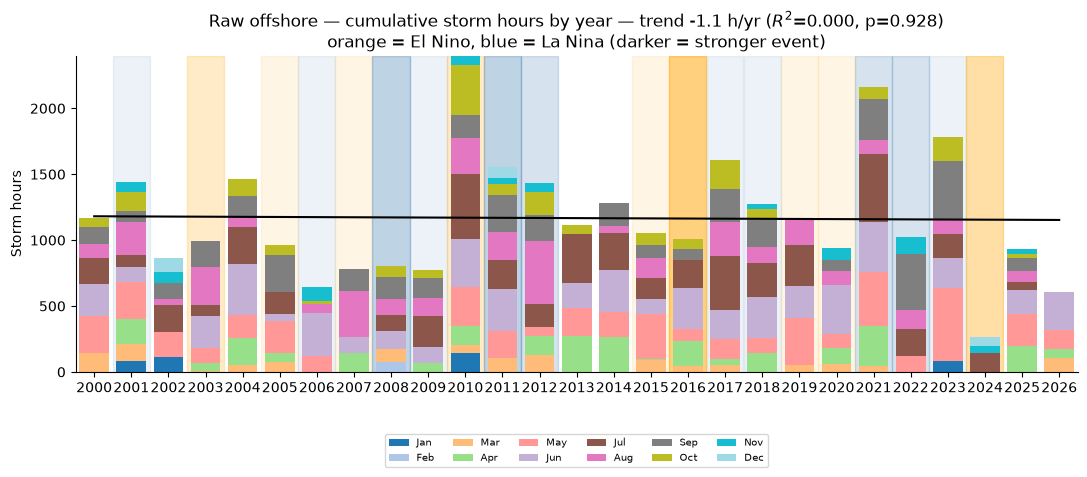

In [37]:
## 1. cumulative storm HOURS by year (raw offshore)
fig, ax = plt.subplots(figsize=(11, 5))
enso_shade(ax)

bottom = np.zeros(len(pivot_hours_raw))
colors = plt.cm.tab20(np.linspace(0, 1, 12))
for m in range(1, 13):
    vals = pivot_hours_raw[m].values
    ax.bar(years_raw, vals, bottom=bottom, width=0.8, color=colors[m - 1], label=month_labels[m - 1], zorder=2)
    bottom += vals

slope, intercept, r, p_val, se = stats.linregress(years_raw, pivot_hours_raw.sum(axis=1).values)
ax.plot(years_raw, slope * years_raw + intercept, color='black', linewidth=1.5, zorder=3)

ax.set_xticks(years_raw); ax.set_xticklabels(pivot_hours_raw.index.astype(str), rotation=0)
ax.set_xlim(years_raw.min() - 0.5, years_raw.max() + 0.5)
ax.set_ylabel('Storm hours')
ax.set_title(f'Raw offshore — cumulative storm hours by year — trend {slope:.1f} h/yr ($R^2$={r**2:.3f}, p={p_val:.3f})\n'
             'orange = El Nino, blue = La Nina (darker = stronger event)')
ax.legend(ncol=6, fontsize=7, bbox_to_anchor=(0.5, -0.18), loc='upper center')
plt.tight_layout(); plt.show()

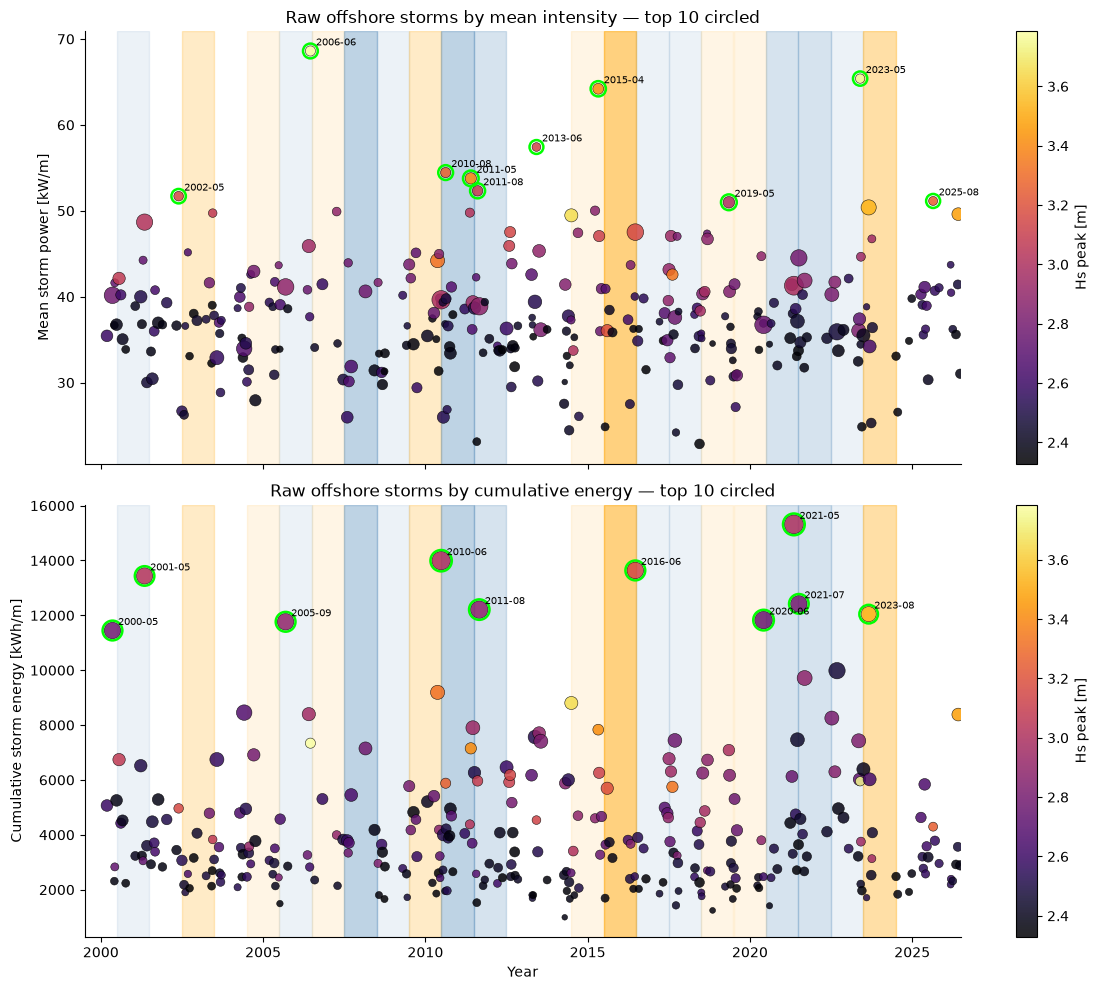

In [38]:
## 3. per-storm intensity — mean power and cumulative energy, strongest 10 circled
N_TOP = 10
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for ax, metric, ylabel, title in [
    (axs[0], 'P_mean_kWm', 'Mean storm power [kW/m]', 'by mean intensity'),
    (axs[1], 'storm_energy_kWhm', 'Cumulative storm energy [kWh/m]', 'by cumulative energy'),
]:
    enso_shade(ax)
    sc = ax.scatter(storms_raw['year_frac'], storms_raw[metric], s=storms_raw['storm_hours'] / 2,
                     c=storms_raw['Hs_peak'], cmap='inferno', edgecolor='black', linewidth=0.4, alpha=0.85, zorder=2)
    top_n = storms_raw.sort_values(metric, ascending=False).head(N_TOP)
    ax.scatter(top_n['year_frac'], top_n[metric], s=top_n['storm_hours'] / 2 + 60,
               facecolors='none', edgecolors='lime', linewidth=1.8, zorder=3)
    for _, s in top_n.iterrows():
        ax.annotate(s['start'].strftime('%Y-%m'), (s['year_frac'], s[metric]), textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_title(f'Raw offshore storms {title} — top {N_TOP} circled')
    plt.colorbar(sc, ax=ax, label='Hs peak [m]')

axs[1].set_xlim(np.floor(years_raw.min()) - 0.5, np.ceil(years_raw.max()) + 0.5)
axs[1].set_xlabel('Year')
plt.tight_layout(); plt.show()

NameError: name 'df_storm_hours' is not defined

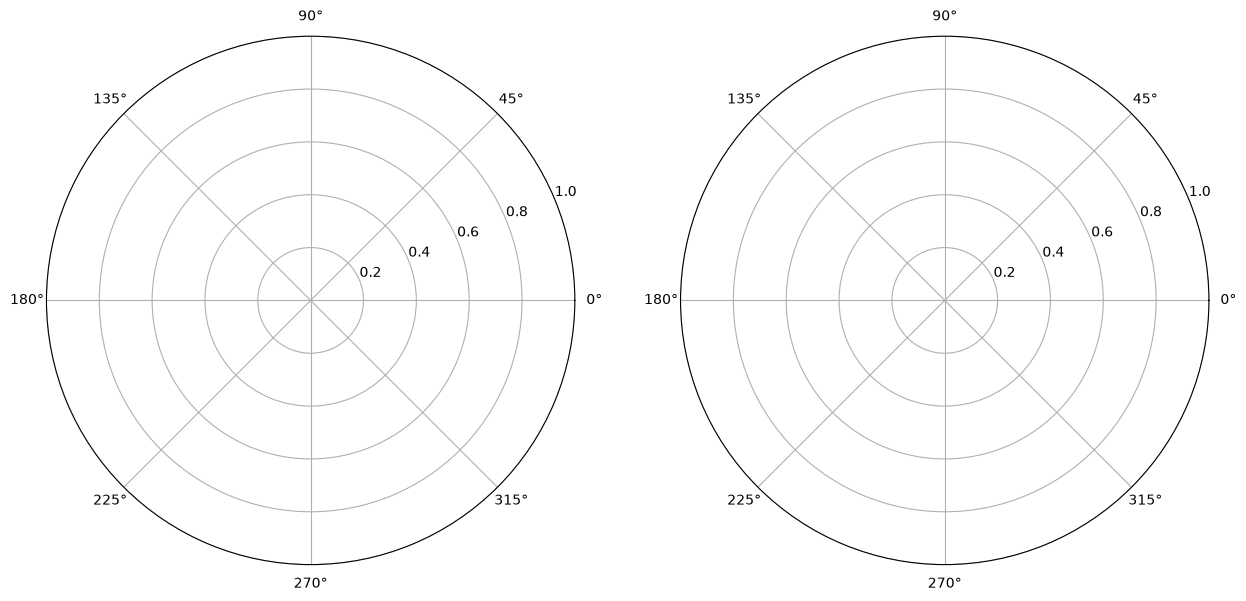

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(15, 8), subplot_kw={'projection': 'polar'})
for ax, phase, label in zip(axs, ['nino', 'nina'], ['El Nino', 'La Nina']):
    sub = df_storm_hours[df_storm_hours['phase'] == phase].dropna(subset=['Dir', 'Hb'])
    wave_rose(ax, sub, label)

rmax = max(ax.get_ylim()[1] for ax in axs)
for ax in axs:
    ax.set_ylim(0, rmax)

axs[0].legend(title='Hb', loc='upper center', bbox_to_anchor=(1.1, -0.08), ncol=5, fontsize=10, frameon=False)
fig.suptitle('Storm wave direction (offshore approach) — El Nino vs La Nina', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

## 6. Where storms come from

Each storm's peak breaking wave height plotted at its offshore approach direction — a compass view of storm origin and severity.

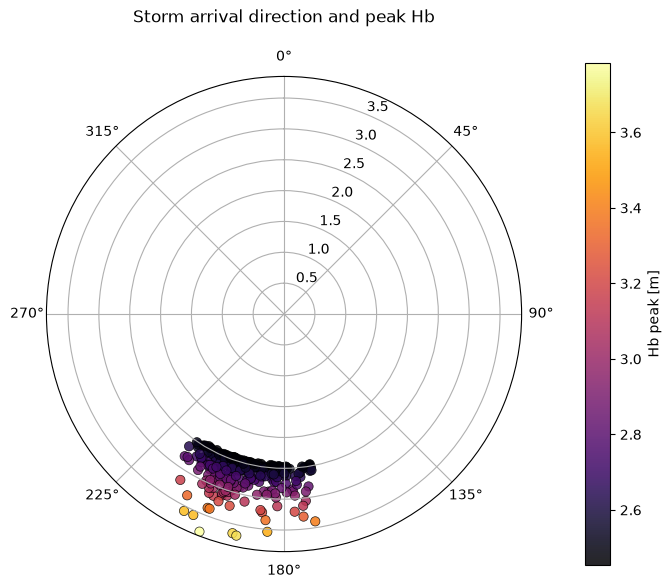

In [12]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
theta = np.radians(storms['direction'])
sc = ax.scatter(theta, storms['Hb_peak'], c=storms['Hb_peak'], cmap='inferno',
                 s=45, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title('Storm arrival direction and peak Hb', pad=20)
plt.colorbar(sc, ax=ax, label='Hb peak [m]', shrink=0.75, pad=0.1)
plt.tight_layout()
plt.show()

## 7. Offshore vs. nearshore transformation

How the nearshore/offshore Hs ratio depends on period and direction. Raw hourly points are binned (to keep the plot readable at this record length) into direction/period groups, plotted as unconnected scatter points with a linear trend line per group; the printed correlation is computed on the full, unbinned hourly record.

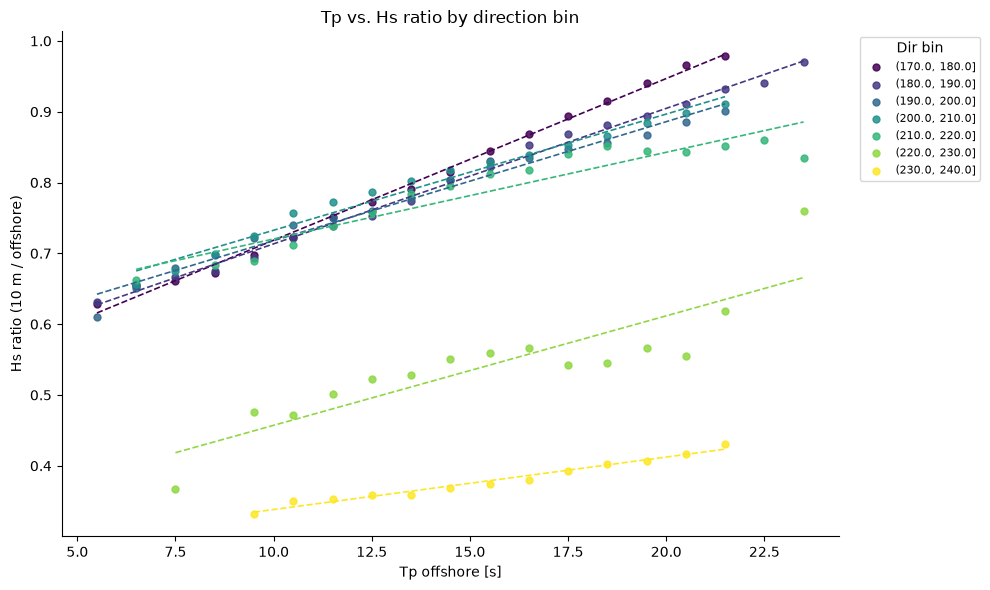

overall correlation, Tp vs. ratio: r = 0.362  (p = 0.00e+00)


In [13]:
tp_bin_width = 1
df['Tp_bin_c'] = (df['Tp_offshore'] // tp_bin_width) * tp_bin_width + tp_bin_width / 2

grp = df.groupby(['Dir_bin', 'Tp_bin_c'], observed=True)['Hs_ratio'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
dir_cats = df['Dir_bin'].cat.categories
colors = plt.cm.viridis(np.linspace(0, 1, len(dir_cats)))

for (dbin, sub), color in zip(grp.groupby('Dir_bin', observed=True), colors):
    if len(sub) < 3:
        continue
    ax.scatter(sub['Tp_bin_c'], sub['Hs_ratio'], s=25, color=color, label=str(dbin), alpha=0.85)
    slope, intercept, r, p_val, se = stats.linregress(sub['Tp_bin_c'], sub['Hs_ratio'])
    x_line = np.linspace(sub['Tp_bin_c'].min(), sub['Tp_bin_c'].max(), 20)
    ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=1.2, linestyle='--')

ax.set_xlabel('Tp offshore [s]')
ax.set_ylabel('Hs ratio (10 m / offshore)')
ax.set_title('Tp vs. Hs ratio by direction bin')
ax.legend(title='Dir bin', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

r_overall, p_overall = stats.pearsonr(df['Tp_offshore'], df['Hs_ratio'])
print(f"overall correlation, Tp vs. ratio: r = {r_overall:.3f}  (p = {p_overall:.2e})")

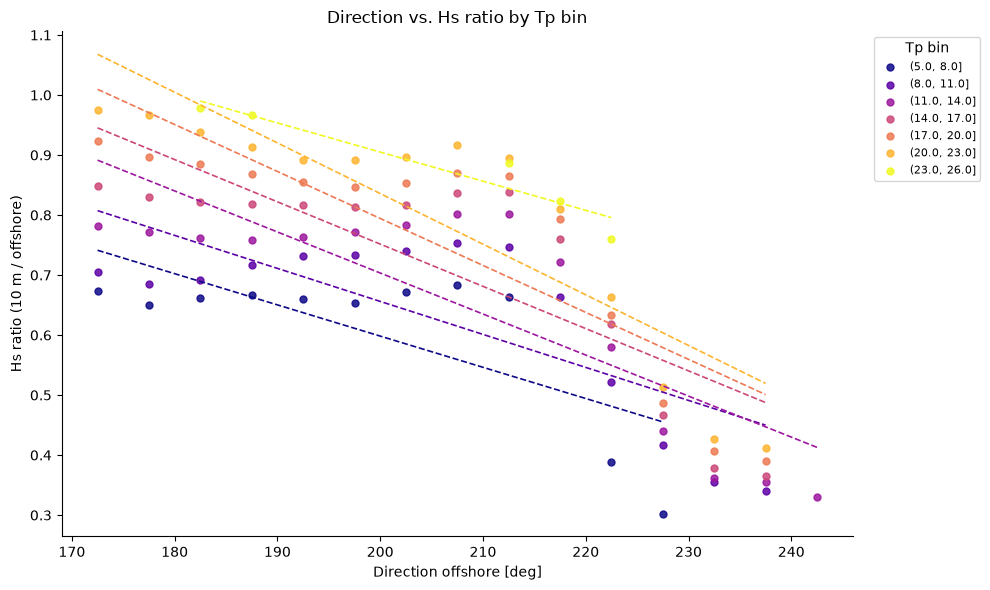

overall correlation, Dir vs. ratio: r = -0.462  (p = 0.00e+00)


In [14]:
tp_group_width = 3
tp_edges = np.arange(np.floor(df['Tp_offshore'].min()), np.ceil(df['Tp_offshore'].max()) + tp_group_width, tp_group_width)
df['Tp_group'] = pd.cut(df['Tp_offshore'], bins=tp_edges)

dir_bin_width = 5
df['Dir_bin_c'] = (df['Dir'] // dir_bin_width) * dir_bin_width + dir_bin_width / 2

grp2 = df.groupby(['Tp_group', 'Dir_bin_c'], observed=True)['Hs_ratio'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
tp_cats = df['Tp_group'].cat.categories
colors2 = plt.cm.plasma(np.linspace(0, 1, len(tp_cats)))

for (tbin, sub), color in zip(grp2.groupby('Tp_group', observed=True), colors2):
    if len(sub) < 3:
        continue
    ax.scatter(sub['Dir_bin_c'], sub['Hs_ratio'], s=25, color=color, label=str(tbin), alpha=0.85)
    slope, intercept, r, p_val, se = stats.linregress(sub['Dir_bin_c'], sub['Hs_ratio'])
    x_line = np.linspace(sub['Dir_bin_c'].min(), sub['Dir_bin_c'].max(), 20)
    ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=1.2, linestyle='--')

ax.set_xlabel('Direction offshore [deg]')
ax.set_ylabel('Hs ratio (10 m / offshore)')
ax.set_title('Direction vs. Hs ratio by Tp bin')
ax.legend(title='Tp bin', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

r_overall2, p_overall2 = stats.pearsonr(df['Dir'], df['Hs_ratio'])
print(f"overall correlation, Dir vs. ratio: r = {r_overall2:.3f}  (p = {p_overall2:.2e})")